Albus there, 
I've done it! 
通过CCD拍摄两张

## 0. 导入依赖

如果在项目根目录运行本 notebook，可以直接导入 `coldatom_imaging`。若还未安装项目，先在终端执行：

```bash
pip install -e .
```

本教程使用 `matplotlib` 画图；如环境缺少它，可执行 `pip install matplotlib`。

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter

from coldatom_imaging import load_image, compute_od, fit_gaussian_2d, get_species

plt.rcParams["figure.dpi"] = 120

## 1. 设置实验参数和图片路径

将 `RUN_DEMO` 改为 `False` 后，填写真实图片路径：

- `probe_path`：有冷原子的图片，即探测光经过原子云后的图像。
- `reference_path`：无冷原子的参考光图片。

相机参数用于把像素面积换算为原子平面的真实面积：

- `pixel_size_um`：相机传感器单个像素尺寸，单位 um。
- `magnification`：成像系统放大率。
- `effective_pixel_um = pixel_size_um / magnification`。

In [11]:
# 若没有实验图片，保持 True 可生成一组模拟图片跑通流程。
RUN_DEMO = False

# 真实实验时填写这两个路径，并将 RUN_DEMO 改为 False。
probe_path = Path("ja.png")
reference_path = Path("nein.png")

# 物种和相机参数。species 可选：Sr, Rb, Cs, Yb, Ca, Dy, Li, Na, K, Er 等。
species_name = "Sr"
pixel_size_um = 6.45
magnification = 1.0

# ROI 格式：(x0, y0, x1, y1)。None 表示使用整张图。
# 实验图片建议先看差分图，再把 ROI 改到只覆盖原子云和少量背景。
roi = None

# OD 截断上限，用于抑制除零、坏点或强噪声导致的异常大值。
od_clamp = 4.0

## 2. 读取两张图片

项目中的 `load_image` 支持 `bmp/png/tiff/tif`，若安装了 `astropy` 也支持 `fits/fit`。RGB 图片会自动转成灰度数组。

In [14]:
def make_demo_images(shape=(220, 260), atom_number_like=1.0):
    """生成一组模拟吸收图：reference 是无原子光场，probe 是被原子云吸收后的光场。"""
    rng = np.random.default_rng(42)
    y, x = np.mgrid[0:shape[0], 0:shape[1]]

    # 模拟参考光场：包含轻微强度梯度和相机噪声。
    reference = 18000 + 500 * (x / shape[1]) + 350 * (y / shape[0])
    reference += rng.normal(0, 80, size=shape)

    # 模拟原子云 OD 分布。
    x0, y0 = shape[1] * 0.52, shape[0] * 0.48
    sx, sy = 24, 18
    peak_od = 1.1 * atom_number_like
    od_true = peak_od * np.exp(-((x - x0) ** 2 / (2 * sx ** 2) + (y - y0) ** 2 / (2 * sy ** 2)))

    # I_probe = I_reference * exp(-OD)。
    probe = reference * np.exp(-od_true)
    probe += rng.normal(0, 80, size=shape)

    return probe.astype(np.float64), reference.astype(np.float64)


if RUN_DEMO:
    probe, reference = make_demo_images()
else:
    probe = load_image(probe_path)
    reference = load_image(reference_path)

probe = np.asarray(probe, dtype=np.float64)
reference = np.asarray(reference, dtype=np.float64)

if probe.shape != reference.shape:
    raise ValueError(f"两张图片尺寸不一致：probe={probe.shape}, reference={reference.shape}")

print(f"probe shape: {probe.shape}, dtype: {probe.dtype}")
print(f"reference shape: {reference.shape}, dtype: {reference.dtype}")

probe shape: (1024, 1536), dtype: float64
reference shape: (1024, 1536), dtype: float64


## 3. 相减得到灰度差分图

有原子时探测光被吸收，所以通常 `reference - probe` 在原子云区域为正。该图适合判断原子云位置、选择 ROI 和检查坏点。

/var/folders/23/dzs5n0z52j19fhf7kg70v5tw0000gn/T/ipykernel_23445/3080255712.py:13: UserWarning: Glyph 26377 (\N{CJK UNIFIED IDEOGRAPH-6709}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/23/dzs5n0z52j19fhf7kg70v5tw0000gn/T/ipykernel_23445/3080255712.py:13: UserWarning: Glyph 20919 (\N{CJK UNIFIED IDEOGRAPH-51B7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/23/dzs5n0z52j19fhf7kg70v5tw0000gn/T/ipykernel_23445/3080255712.py:13: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/23/dzs5n0z52j19fhf7kg70v5tw0000gn/T/ipykernel_23445/3080255712.py:13: UserWarning: Glyph 23376 (\N{CJK UNIFIED IDEOGRAPH-5B50}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/23/dzs5n0z52j19fhf7kg70v5tw0000gn/T/ipykernel_23445/3080255712.py:13: UserWarning: Glyph 26080 (\N{CJK UNIFIED IDEOGRAPH-65E0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/23/dzs5

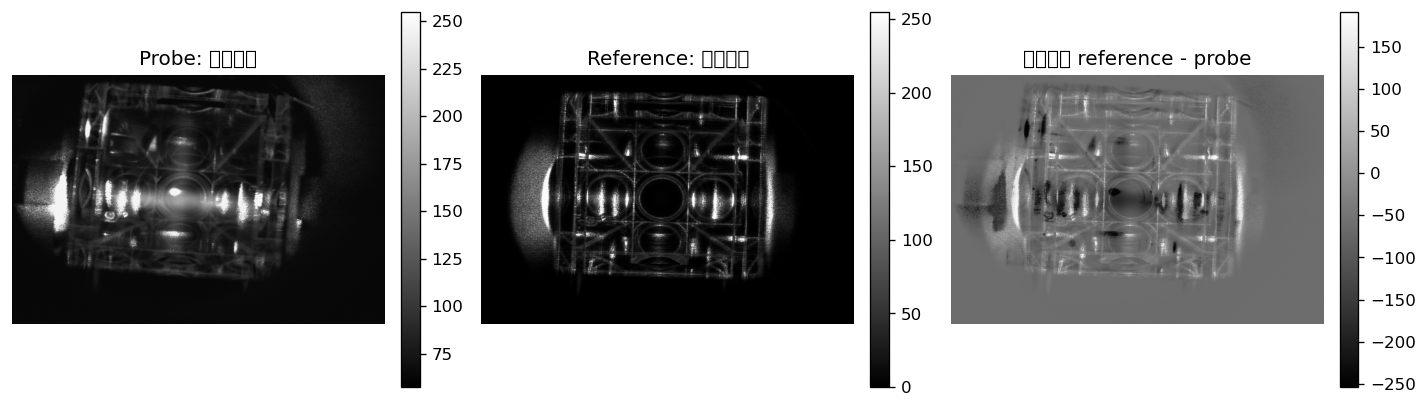

In [15]:
gray_diff = reference - probe

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
images = [probe, reference, gray_diff]
titles = ["Probe: 有冷原子", "Reference: 无冷原子", "灰度差分 reference - probe"]

for ax, img, title in zip(axes, images, titles):
    im = ax.imshow(img, cmap="gray")
    ax.set_title(title)
    ax.set_axis_off()
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()

## 4. 预处理

这里采用最小必要预处理：

1. 限制强度下限，避免除零和 `log` 异常。
2. 计算 OD 并截断异常值。
3. 可选中值滤波抑制孤立坏点。
4. 可选 ROI 裁剪，只积分原子云区域。

若实验中有暗场图，当前项目也支持 `compute_od(probe, reference, dark=dark_image)`，本教程按用户要求只使用两张图片。

/var/folders/23/dzs5n0z52j19fhf7kg70v5tw0000gn/T/ipykernel_23445/2798766162.py:28: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/23/dzs5n0z52j19fhf7kg70v5tw0000gn/T/ipykernel_23445/2798766162.py:28: UserWarning: Glyph 22788 (\N{CJK UNIFIED IDEOGRAPH-5904}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/23/dzs5n0z52j19fhf7kg70v5tw0000gn/T/ipykernel_23445/2798766162.py:28: UserWarning: Glyph 29702 (\N{CJK UNIFIED IDEOGRAPH-7406}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/23/dzs5n0z52j19fhf7kg70v5tw0000gn/T/ipykernel_23445/2798766162.py:28: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/23/dzs5n0z52j19fhf7kg70v5tw0000gn/T/ipykernel_23445/2798766162.py:28: UserWarning: Glyph 28784 (\N{CJK UNIFIED IDEOGRAPH-7070}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/23/dzs5

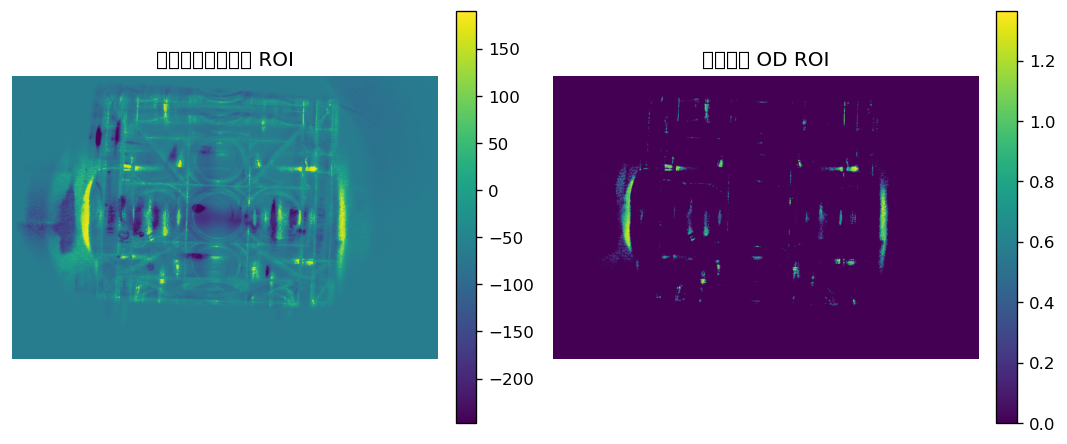

In [16]:
# 项目已有函数：OD = -ln(probe / reference)，内部会把非正强度限制到 1，并做 OD 截断。
od = compute_od(probe, reference, dark=None, clamp=od_clamp)

# 对差分图和 OD 图做轻度中值滤波。若不希望滤波，可将 size 改成 1。
median_size = 3
gray_diff_pre = median_filter(gray_diff, size=median_size)
od_pre = median_filter(od, size=median_size)

def crop_roi(image, roi):
    if roi is None:
        return image
    x0, y0, x1, y1 = roi
    return image[y0:y1, x0:x1]

gray_diff_roi = crop_roi(gray_diff_pre, roi)
od_roi = crop_roi(od_pre, roi)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
for ax, img, title in [
    (axes[0], gray_diff_roi, "预处理后灰度差分 ROI"),
    (axes[1], od_roi, "预处理后 OD ROI"),
]:
    im = ax.imshow(img, cmap="viridis")
    ax.set_title(title)
    ax.set_axis_off()
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()

## 5. 积分灰度与积分 OD

灰度差分积分：

`S_gray = sum(reference - probe)`

它的单位是相机计数值，依赖曝光、增益、光强和相机响应，通常不能直接得到原子数。

吸收成像用于原子数计算的是积分 OD：

`integral_OD = sum(OD_pixel) * pixel_area`

其中 `pixel_area` 是原子平面上单个像素对应面积，单位 `m^2`。

In [17]:
effective_pixel_um = pixel_size_um / magnification
pixel_area_m2 = (effective_pixel_um * 1e-6) ** 2

integrated_gray_counts = np.sum(gray_diff_roi)
integrated_od_area = np.sum(od_roi) * pixel_area_m2

print(f"effective pixel size = {effective_pixel_um:.4g} um/px")
print(f"pixel area = {pixel_area_m2:.4e} m^2/px")
print(f"integrated gray counts = {integrated_gray_counts:.4e} counts")
print(f"integrated OD area = {integrated_od_area:.4e} m^2")

effective pixel size = 6.45 um/px
pixel area = 4.1602e-11 m^2/px
integrated gray counts = -1.0038e+08 counts
integrated OD area = 9.9884e-07 m^2


## 6. 代入理论公式求冷原子数

对理想二能级闭合跃迁，项目中采用共振散射截面：

`sigma0 = 3 lambda^2 / (2 pi)`

柱密度满足：

`OD(x,y) = sigma0 * n_col(x,y)`

因此总原子数：

`N = integral OD(x,y) dA / sigma0`

注意：真实实验可能还需要修正偏振、跃迁 Clebsch-Gordan 系数、探测光失谐、饱和强度和光泵浦效应。当前项目的 `sigma0` 是基础共振截面。

In [18]:
species = get_species(species_name)
sigma0 = species.sigma0
atom_number_from_sum = integrated_od_area / sigma0

print(f"species = {species.name} ({species.symbol})")
print(f"lambda = {species.wavelength_nm:.3f} nm")
print(f"sigma0 = {sigma0:.4e} m^2")
print(f"Atom number from summed OD = {atom_number_from_sum:.4e}")

species = Strontium-88 (Sr88)
lambda = 460.862 nm
sigma0 = 1.0141e-13 m^2
Atom number from summed OD = 9.8494e+06


## 7. 可选：使用项目已有二维高斯拟合

当前项目还提供 `fit_gaussian_2d`。它先拟合 OD 图：

`OD = A exp(-((x-x0)^2/(2 sigma_x^2) + (y-y0)^2/(2 sigma_y^2))) + C`

再用高斯积分：

`N = 2 pi A sigma_x sigma_y pixel_area / sigma0`

这适合原子云形状接近二维高斯的情况。若云形不规则，直接积分 OD 往往更稳健。

In [ ]:
fit = fit_gaussian_2d(od_roi, effective_pixel_um=effective_pixel_um, sigma0=sigma0)

print(fit.summary())

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, img, title in [
    (axes[0], od_roi, "OD ROI"),
    (axes[1], fit.fit_image, "2D Gaussian fit"),
    (axes[2], fit.residual, "Residual"),
]:
    im = ax.imshow(img, cmap="viridis")
    ax.set_title(title)
    ax.set_axis_off()
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()

## 8. 结果汇总

建议报告时同时记录以下信息：

- 两张原始图片路径。
- 物种、波长、`sigma0`。
- 相机像素尺寸、放大率、有效像素尺寸。
- ROI 范围和预处理方式。
- 直接积分 OD 得到的原子数。
- 若使用高斯拟合，也记录拟合原子数、中心、云团尺寸和残差。

In [9]:
summary = {
    "species": species.symbol,
    "wavelength_nm": species.wavelength_nm,
    "sigma0_m2": sigma0,
    "pixel_size_um": pixel_size_um,
    "magnification": magnification,
    "effective_pixel_um": effective_pixel_um,
    "roi": roi,
    "integrated_gray_counts": integrated_gray_counts,
    "integrated_od_area_m2": integrated_od_area,
    "atom_number_from_summed_od": atom_number_from_sum,
    "atom_number_from_gaussian_fit": fit.atom_number,
    "fit_center_px": (fit.center_x_px, fit.center_y_px),
    "fit_sigma_um": (fit.sigma_x_um, fit.sigma_y_um),
    "fit_success": fit.success,
}

for key, value in summary.items():
    print(f"{key}: {value}")

NameError: name 'fit' is not defined